<a href="https://colab.research.google.com/github/Nikhilsankhyan0/Agrisheild-AI/blob/main/classification_model_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:


import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Features
x_train = pd.read_csv(
    "/content/drive/MyDrive/X_train_encoded.csv"
)

x_val = pd.read_csv(
    "/content/drive/MyDrive/X_val_encoded.csv"
)

x_test = pd.read_csv(
    "/content/drive/MyDrive/X_test_encoded.csv"
)

# Classification target
y_train_cls = pd.read_csv(
    "/content/drive/MyDrive/y_train_cls.csv"
).squeeze()

y_val_cls = pd.read_csv(
    "/content/drive/MyDrive/y_val_cls.csv"
).squeeze()

y_test_cls = pd.read_csv(
    "/content/drive/MyDrive/y_test_cls.csv"
).squeeze()

print("X_train:", x_train.shape)
print("X_val  :", x_val.shape)
print("X_test :", x_test.shape)

print("y_train:", y_train_cls.shape)
print("y_val  :", y_val_cls.shape)
print("y_test :", y_test_cls.shape)

X_train: (14000, 259)
X_val  : (3000, 259)
X_test : (3000, 259)
y_train: (14000,)
y_val  : (3000,)
y_test : (3000,)


encode loan status

In [3]:
label_encoder = LabelEncoder()

y_train_cls_encoded = label_encoder.fit_transform(
    y_train_cls
)

y_val_cls_encoded = label_encoder.transform(
    y_val_cls
)

y_test_cls_encoded = label_encoder.transform(
    y_test_cls
)

print("Class mapping:")

for class_name, class_number in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(class_name, "→", class_number)

Class mapping:
Approved → 0
Approved with Conditions → 1
Rejected → 2


In [4]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_val_scaled = scaler.transform(x_val)

x_test_scaled = scaler.transform(x_test)

In [5]:
baseline_cls = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_cls.fit(
    x_train_scaled,
    y_train_cls_encoded
)

LogisticRegression(max_iter=1000, random_state=42)

In [6]:
y_pred_cls = baseline_cls.predict(
    x_val_scaled
)


In [7]:
y_pred_cls = baseline_cls.predict(
    x_val_scaled
)

In [8]:
y_pred_cls = baseline_cls.predict(
    x_val_scaled
)

In [9]:
cm = confusion_matrix(
    y_val_cls_encoded,
    y_pred_cls
)

print(cm)

[[636 210   2]
 [164 943 133]
 [ 10 168 734]]


In [11]:
print(
    classification_report(
        y_val_cls_encoded,
        y_pred_cls,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

                Approved       0.79      0.75      0.77       848
Approved with Conditions       0.71      0.76      0.74      1240
                Rejected       0.84      0.80      0.82       912

                accuracy                           0.77      3000
               macro avg       0.78      0.77      0.78      3000
            weighted avg       0.77      0.77      0.77      3000



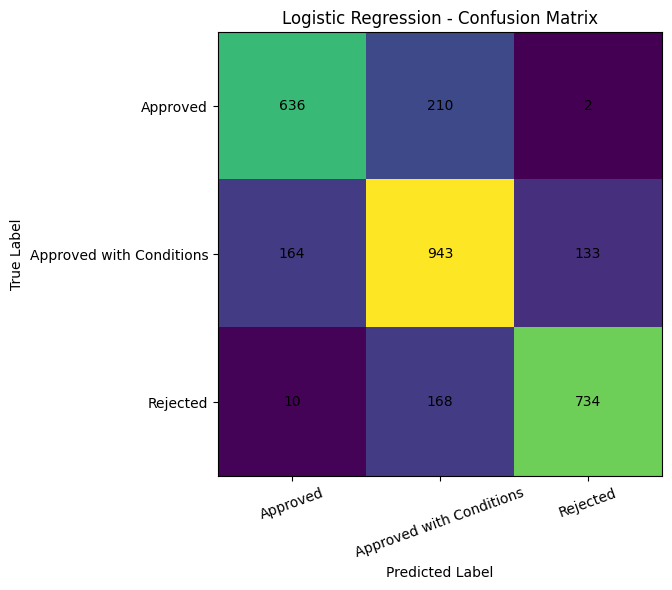

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=20
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression - Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

Decision tree

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [14]:
dt_classifier = DecisionTreeClassifier(
    random_state=42
)

dt_classifier.fit(
    x_train,
    y_train_cls_encoded
)

DecisionTreeClassifier(random_state=42)

In [15]:
y_pred_dt = dt_classifier.predict(
    x_val
)

In [17]:
accuracy_dt = accuracy_score(
    y_val_cls_encoded,
    y_pred_dt
)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.7066666666666667


In [18]:
print(
    classification_report(
        y_val_cls_encoded,
        y_pred_dt,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

                Approved       0.74      0.71      0.72       848
Approved with Conditions       0.67      0.68      0.67      1240
                Rejected       0.73      0.74      0.74       912

                accuracy                           0.71      3000
               macro avg       0.71      0.71      0.71      3000
            weighted avg       0.71      0.71      0.71      3000



In [19]:
cm_dt = confusion_matrix(
    y_val_cls_encoded,
    y_pred_dt
)

print(cm_dt)

[[598 214  36]
 [184 843 213]
 [ 26 207 679]]


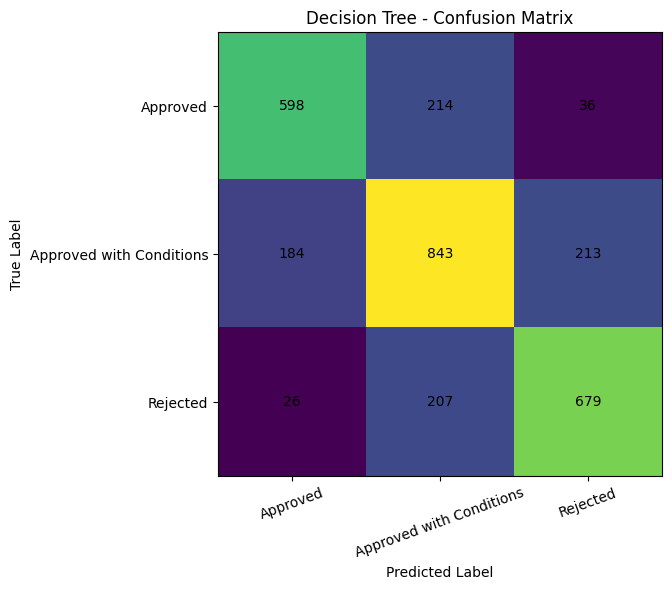

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.imshow(cm_dt)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=20
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree - Confusion Matrix")

for i in range(cm_dt.shape[0]):
    for j in range(cm_dt.shape[1]):
        plt.text(
            j,
            i,
            cm_dt[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

random forest

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_classifier.fit(
    x_train,
    y_train_cls_encoded
)

y_pred_rf = rf_classifier.predict(
    x_val
)

In [22]:
accuracy_rf = accuracy_score(
    y_val_cls_encoded,
    y_pred_rf
)

print("===== RANDOM FOREST BASELINE =====")
print(f"Accuracy : {accuracy_rf:.4f}")

In [23]:
print(
    classification_report(
        y_val_cls_encoded,
        y_pred_rf,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

                Approved       0.79      0.83      0.81       848
Approved with Conditions       0.72      0.77      0.74      1240
                Rejected       0.85      0.73      0.79       912

                accuracy                           0.78      3000
               macro avg       0.79      0.78      0.78      3000
            weighted avg       0.78      0.78      0.78      3000



In [24]:
cm_rf = confusion_matrix(
    y_val_cls_encoded,
    y_pred_rf
)

print(cm_rf)

[[703 144   1]
 [167 955 118]
 [ 16 228 668]]


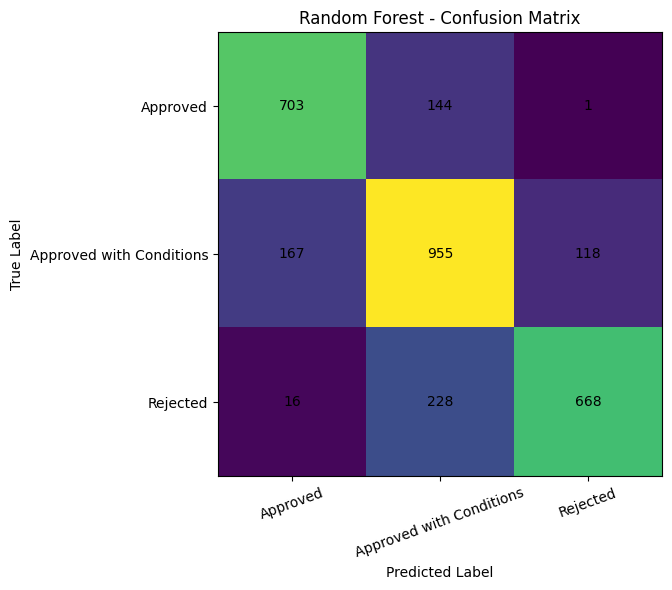

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.imshow(cm_rf)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=20
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Confusion Matrix")

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

tuninig Random forest

In [27]:
rf_models = {

    "RF_100": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "RF_200": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "RF_depth10": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),

    "RF_depth20": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),

    "RF_leaf2": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

In [29]:
rf_results = []

for name, model in rf_models.items():

    model.fit(
        x_train,
        y_train_cls_encoded
    )

    y_pred = model.predict(
        x_val
    )

    accuracy = accuracy_score(
        y_val_cls_encoded,
        y_pred
    )

    report = classification_report(
        y_val_cls_encoded,
        y_pred,
        output_dict=True
    )

    macro_f1 = report["macro avg"]["f1-score"]

    rf_results.append([
        name,
        accuracy,
        macro_f1
    ])

In [30]:
rf_results_df = pd.DataFrame(
    rf_results,
    columns=[
        "Model",
        "Accuracy",
        "Macro_F1"
    ]
)

rf_results_df = rf_results_df.sort_values(
    "Macro_F1",
    ascending=False
)

print(rf_results_df)

        Model  Accuracy  Macro_F1
4    RF_leaf2  0.776667  0.781691
3  RF_depth20  0.776333  0.781233
0      RF_100  0.775667  0.780535
1      RF_200  0.775333  0.780415
2  RF_depth10  0.767667  0.772160


XGboosting classifier

In [31]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [32]:
xgb_classifier = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

In [34]:
xgb_classifier.fit(
    x_train,
    y_train_cls_encoded
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [35]:
y_pred_xgb = xgb_classifier.predict(
    x_val
)

In [36]:
accuracy_xgb = accuracy_score(
    y_val_cls_encoded,
    y_pred_xgb
)

print("===== XGBOOST BASELINE =====")
print(f"Accuracy : {accuracy_xgb:.4f}")

===== XGBOOST BASELINE =====
Accuracy : 0.7873


In [37]:
print(
    classification_report(
        y_val_cls_encoded,
        y_pred_xgb,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

                Approved       0.77      0.88      0.82       848
Approved with Conditions       0.76      0.74      0.75      1240
                Rejected       0.84      0.77      0.81       912

                accuracy                           0.79      3000
               macro avg       0.79      0.80      0.79      3000
            weighted avg       0.79      0.79      0.79      3000



tune n-Estimators

In [38]:
xgb_models = {

    "XGB_100": XGBClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "XGB_200": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "XGB_300": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
}

In [39]:
xgb_results = []

for name, model in xgb_models.items():

    model.fit(
        x_train,
        y_train_cls_encoded
    )

    y_pred = model.predict(
        x_val
    )

    accuracy = accuracy_score(
        y_val_cls_encoded,
        y_pred
    )

    report = classification_report(
        y_val_cls_encoded,
        y_pred,
        output_dict=True
    )

    macro_f1 = report["macro avg"]["f1-score"]

    xgb_results.append([
        name,
        accuracy,
        macro_f1
    ])

In [40]:
xgb_results_df = pd.DataFrame(
    xgb_results,
    columns=[
        "Model",
        "Accuracy",
        "Macro_F1"
    ]
)

print(
    xgb_results_df.sort_values(
        "Macro_F1",
        ascending=False
    )
)

     Model  Accuracy  Macro_F1
2  XGB_300  0.795333  0.800197
1  XGB_200  0.787333  0.792172
0  XGB_100  0.772667  0.777061


the best parameters

n_estimators = 300

learning_rate = 0.05

max_depth = 3

tune max_depth

In [42]:
xgb_depth_models = {

    "XGB_depth2": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=2,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "XGB_depth3": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "XGB_depth4": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "XGB_depth5": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
}

In [43]:
xgb_depth_results = []

for name, model in xgb_depth_models.items():

    model.fit(
        x_train,
        y_train_cls_encoded
    )

    y_pred = model.predict(x_val)

    accuracy = accuracy_score(
        y_val_cls_encoded,
        y_pred
    )

    report = classification_report(
        y_val_cls_encoded,
        y_pred,
        output_dict=True
    )

    macro_f1 = report["macro avg"]["f1-score"]

    xgb_depth_results.append([
        name,
        accuracy,
        macro_f1
    ])

In [44]:
xgb_depth_results_df = pd.DataFrame(
    xgb_depth_results,
    columns=[
        "Model",
        "Accuracy",
        "Macro_F1"
    ]
)

print(
    xgb_depth_results_df.sort_values(
        "Macro_F1",
        ascending=False
    )
)

        Model  Accuracy  Macro_F1
3  XGB_depth5  0.799000  0.804060
2  XGB_depth4  0.798000  0.803059
1  XGB_depth3  0.795333  0.800197
0  XGB_depth2  0.785333  0.790084


depth 2 is best


n_estimators = 300
max_depth = 5

tuning learnig rate now

In [45]:
xgb_lr_models = {

    "XGB_lr_0.03": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "XGB_lr_0.05": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "XGB_lr_0.10": XGBClassifier(
        n_estimators=300,
        learning_rate=0.10,
        max_depth=5,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
}

In [46]:
xgb_lr_results = []

for name, model in xgb_lr_models.items():

    model.fit(
        x_train,
        y_train_cls_encoded
    )

    y_pred = model.predict(x_val)

    accuracy = accuracy_score(
        y_val_cls_encoded,
        y_pred
    )

    report = classification_report(
        y_val_cls_encoded,
        y_pred,
        output_dict=True
    )

    macro_f1 = report["macro avg"]["f1-score"]

    xgb_lr_results.append([
        name,
        accuracy,
        macro_f1
    ])

In [47]:
xgb_lr_results_df = pd.DataFrame(
    xgb_lr_results,
    columns=[
        "Model",
        "Accuracy",
        "Macro_F1"
    ]
)

print(
    xgb_lr_results_df.sort_values(
        "Macro_F1",
        ascending=False
    )
)

         Model  Accuracy  Macro_F1
1  XGB_lr_0.05  0.799000  0.804060
0  XGB_lr_0.03  0.797667  0.802735
2  XGB_lr_0.10  0.796333  0.801206


best configuration
XGBoost Classifier

n_estimators  = 300
max_depth     = 5
learning_rate = 0.05

Accuracy      = 0.7990
Macro F1      = 0.8041

In [49]:
final_xgb_candidate = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

final_xgb_candidate.fit(
    x_train,
    y_train_cls_encoded
)

y_pred_final_xgb = final_xgb_candidate.predict(
    x_val
)

print(
    classification_report(
        y_val_cls_encoded,
        y_pred_final_xgb,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

                Approved       0.80      0.85      0.82       848
Approved with Conditions       0.76      0.77      0.76      1240
                Rejected       0.85      0.80      0.82       912

                accuracy                           0.80      3000
               macro avg       0.81      0.80      0.80      3000
            weighted avg       0.80      0.80      0.80      3000



test subsample

In [50]:
xgb_subsample_models = {

    "XGB_subsample_0.8": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "XGB_subsample_1.0": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=1.0,
        random_state=42,
        n_jobs=-1,
        eval_metric="mlogloss"
    )
}

In [51]:
xgb_subsample_results = []

for name, model in xgb_subsample_models.items():

    model.fit(
        x_train,
        y_train_cls_encoded
    )

    y_pred = model.predict(x_val)

    accuracy = accuracy_score(
        y_val_cls_encoded,
        y_pred
    )

    report = classification_report(
        y_val_cls_encoded,
        y_pred,
        output_dict=True
    )

    macro_f1 = report["macro avg"]["f1-score"]

    xgb_subsample_results.append([
        name,
        accuracy,
        macro_f1
    ])

xgb_subsample_results_df = pd.DataFrame(
    xgb_subsample_results,
    columns=[
        "Model",
        "Accuracy",
        "Macro_F1"
    ]
)

print(
    xgb_subsample_results_df.sort_values(
        "Macro_F1",
        ascending=False
    )
)

               Model  Accuracy  Macro_F1
0  XGB_subsample_0.8     0.800  0.805053
1  XGB_subsample_1.0     0.799  0.804060


XGBoost Classifier

n_estimators  = 300
max_depth     = 5
learning_rate = 0.05
subsample     = 0.8

Validation Accuracy = 0.8000
Validation Macro F1 = 0.8051

final model and final testing

In [52]:
# Combine training and validation data

x_train_final = pd.concat(
    [x_train, x_val],
    axis=0
).reset_index(drop=True)

y_train_final = pd.concat(
    [
        pd.Series(y_train_cls_encoded),
        pd.Series(y_val_cls_encoded)
    ],
    axis=0
).reset_index(drop=True)

print("Final X shape:", x_train_final.shape)
print("Final y shape:", y_train_final.shape)

Final X shape: (17000, 259)
Final y shape: (17000,)


In [53]:
from xgboost import XGBClassifier

final_xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

In [54]:
final_xgb_model.fit(
    x_train_final,
    y_train_final
)

print("Final XGBoost model trained successfully.")

Final XGBoost model trained successfully.


In [55]:
y_pred_test_cls = final_xgb_model.predict(
    x_test
)

In [56]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(
    y_test_cls_encoded,
    y_pred_test_cls
)

print("===== FINAL XGBOOST TEST RESULT =====")
print(f"Accuracy : {test_accuracy:.4f}")

===== FINAL XGBOOST TEST RESULT =====
Accuracy : 0.8007


In [57]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_cls_encoded,
        y_pred_test_cls,
        target_names=label_encoder.classes_
    )
)

                          precision    recall  f1-score   support

                Approved       0.81      0.87      0.84       849
Approved with Conditions       0.75      0.79      0.77      1239
                Rejected       0.87      0.75      0.81       912

                accuracy                           0.80      3000
               macro avg       0.81      0.80      0.81      3000
            weighted avg       0.80      0.80      0.80      3000



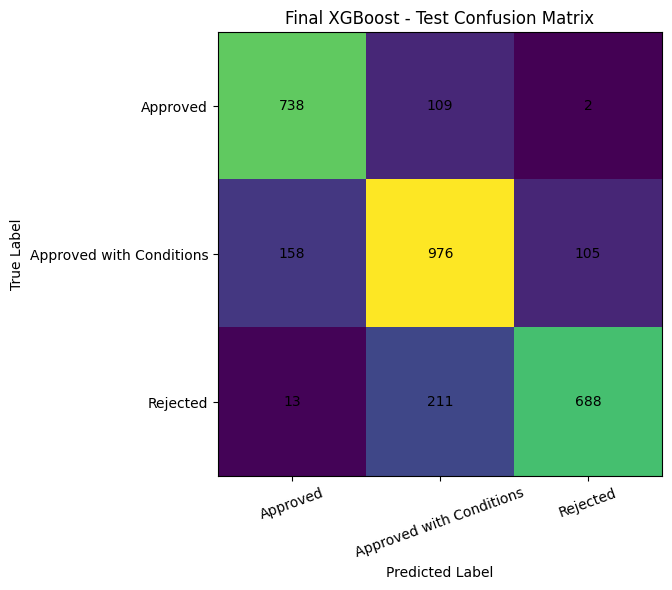

In [58]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_final = confusion_matrix(
    y_test_cls_encoded,
    y_pred_test_cls
)

plt.figure(figsize=(7, 6))

plt.imshow(cm_final)

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=20
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final XGBoost - Test Confusion Matrix")

for i in range(cm_final.shape[0]):
    for j in range(cm_final.shape[1]):
        plt.text(
            j,
            i,
            cm_final[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [59]:
from sklearn.metrics import f1_score

test_macro_f1 = f1_score(
    y_test_cls_encoded,
    y_pred_test_cls,
    average="macro"
)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Macro F1 : {test_macro_f1:.4f}")

Test Accuracy : 0.8007
Test Macro F1 : 0.8052


In [60]:
import joblib

joblib.dump(
    final_xgb_model,
    "/content/drive/MyDrive/final_xgb_classifier.pkl"
)

joblib.dump(
    label_encoder,
    "/content/drive/MyDrive/classification_label_encoder.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.
